
# Algorithmic Fairness — Baseline Bias Analysis in the UCI Adult Dataset
### MSc Data Science Assignment

**Objective:** Evaluate how machine learning models can inadvertently perpetuate discrimination by calculating error-rate disparities across protected groups.

**Dataset:** UCI Adult Dataset (OpenML ID: 1590)  
**Target Variable:** Income (>50K vs <=50K)  
**Sensitive Attributes:** Sex (Male/Female) and Race (White/Black)  
**Model:** Baseline Random Forest Classifier  
**Important:** This notebook measures baseline discrimination only and does **not** apply bias mitigation techniques.


### Dataset Reference

For additional context or alternative implementations, refer to this Kaggle notebook:
[UCI Adult Dataset Kaggle Notebook](https://www.kaggle.com/code/jyoti06/uci-adult-dataset)


## Academic Context

Algorithmic fairness investigates whether predictive systems produce systematically unequal outcomes across demographic groups.  
Even when protected attributes are not explicitly targeted, historical inequalities embedded in training data can create disparate error rates.

This notebook focuses on four fairness metrics:

- **False Positive Rate (FPR):** Incorrectly predicting high income
- **False Negative Rate (FNR):** Incorrectly denying high income
- **False Discovery Rate (FDR):** Positive predictions that are wrong
- **False Omission Rate (FOR):** Negative predictions that are wrong

Disparities in these rates may indicate structural bias in economic opportunity prediction systems.


In [11]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

sns.set_theme(style="whitegrid")


## Step 1 — Load the UCI Adult Dataset from OpenML

### Code Explanation: Loading the UCI Adult Dataset

This section is dedicated to loading the UCI Adult dataset, which is the foundation for our fairness analysis. As per the assignment requirement, the dataset is loaded using `fetch_openml` from the OpenML repository.

**How it fulfills the requirement:**

1.  **`fetch_openml(data_id=1590)`:** This function directly retrieves the UCI Adult dataset using its OpenML ID, ensuring the correct and standardized version of the dataset is used.
2.  **`as_frame=True`:** This parameter ensures that the data is returned as a pandas DataFrame, which is convenient for subsequent data manipulation and analysis.
3.  **`df = adult.frame.copy()`:** The `fetch_openml` function returns a `Bunch` object, and the actual DataFrame is accessed via the `.frame` attribute. A `.copy()` is made to prevent `SettingWithCopyWarning` in future operations.

**Implementation Details:**

*   `from sklearn.datasets import fetch_openml`: Imports the necessary function.
*   `adult = fetch_openml(data_id=1590, as_frame=True)`: Loads the dataset.
*   `df = adult.frame.copy()`: Creates a mutable copy of the DataFrame.
*   `print("Dataset Shape:", df.shape)` and `df.head()`: These lines are used for initial inspection, showing the dimensions of the loaded DataFrame and the first few rows to confirm successful loading.

In [12]:
from sklearn.datasets import fetch_openml

# Load the Adult dataset from OpenML (ID: 1590)
adult = fetch_openml(data_id=1590, as_frame=True)
df = adult.frame.copy()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## Step 2 — Data Cleaning and Preprocessing

In [13]:
# Remove whitespace from object columns
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = df[col].astype(str).str.strip()

# Drop rows with any missing values (fetch_openml often represents missing values as None/NaN already)
df.dropna(inplace=True)

# Preserve sensitive attributes before encoding
df['sex_raw'] = df['sex']
df['race_raw'] = df['race']

# Binary target conversion for 'class' column (from fetch_openml)
# It usually has '<=50K' and '>50K'
df['income'] = df['class'].map({'<=50K': 0, '>50K': 1})

# Drop the original 'class' column after conversion
df.drop(columns=['class'], inplace=True)

# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object', 'category']).columns:
    # Exclude raw sensitive attributes and the target variable 'income' (which is now int)
    if col not in ['sex_raw', 'race_raw', 'income']:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

print("Cleaned Shape:", df.shape)
df.head()

Cleaned Shape: (48842, 17)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,sex_raw,race_raw,income
0,25,3,226802,1,7,4,6,3,2,1,0,0,40,38,Male,Black,0
1,38,3,89814,11,9,2,4,0,4,1,0,0,50,38,Male,White,0
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,38,Male,White,1
3,44,3,160323,15,10,2,6,0,2,1,7688,0,40,38,Male,Black,1
4,18,8,103497,15,10,4,14,3,4,0,0,0,30,38,Female,White,0


### Code Explanation: Data Cleaning and Preprocessing

This section prepares the raw UCI Adult dataset for model training and fairness analysis. It addresses common data quality issues such as whitespace, missing values, and ensures data types are suitable for machine learning, while also preserving the original sensitive attribute values for fairness evaluation.

**How it fulfills the requirement:**

1.  **Whitespace Removal:** Many categorical features in this dataset contain leading/trailing whitespace, which can lead to multiple representations of the same category (e.g., ' Private' vs. 'Private'). Removing this ensures consistent encoding.
2.  **Missing Value Handling:** Explicitly dropping rows with `NaN` values (which were created from ' ?' in the loading step) ensures a clean dataset for training. For this baseline analysis, simple removal is chosen over imputation to maintain clarity.
3.  **Sensitive Attribute Preservation:** The original 'sex' and 'race' columns are duplicated into `sex_raw` and `race_raw` *before* any encoding. This is critical because fairness metrics require these original, human-readable labels to group and compare outcomes.
4.  **Target Variable Transformation:** The 'class' column (income) is converted into a binary numerical format (0 for `<=50K`, 1 for `>50K`), which is required for classification models.
5.  **Categorical Encoding:** All remaining categorical features are transformed into numerical representations using `LabelEncoder`. This is a necessary step for most machine learning algorithms, including the RandomForestClassifier.

**Implementation Details:**

*   **Whitespace Removal:** A loop iterates through object (string) columns, stripping whitespace using `.str.strip()`.
*   **Missing Value Handling:** `df.replace('?', np.nan, inplace=True)` ensures any '?' that might have been missed or introduced later are converted to `NaN`. `df.dropna(inplace=True)` removes all rows containing any `NaN` values.
*   **Sensitive Attribute Preservation:** `df['sex_raw'] = df['sex']` and `df['race_raw'] = df['race']` create copies of these columns.
*   **Target Conversion:** `df['income'] = (df['class'].str.replace('.', '', regex=False).map({'<=50K': 0, '>50K': 1}))` performs the binary mapping and removes a trailing dot from the original labels.
*   **Original Target Drop:** `df.drop(columns=['class'], inplace=True)` removes the original string-based 'class' column.
*   **Label Encoding:** A dictionary `label_encoders` stores `LabelEncoder` objects for each categorical column (excluding `sex_raw` and `race_raw`) to allow for inverse transformation if needed (though not used in this notebook).

## Step 3 — Train/Test Split and Baseline Random Forest Training

In [14]:
X = df.drop(columns=['income', 'sex_raw', 'race_raw'])
y = df['income']

X_train, X_test, y_train, y_test, _, sex_test, _, race_test = train_test_split(
    X, y, df['sex_raw'], df['race_raw'],
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Overall Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))

Overall Accuracy: 0.8604
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      7431
           1       0.75      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.85      0.86      0.86      9769



### Code Explanation: Train/Test Split and Baseline Random Forest Training

This section focuses on preparing the data for machine learning by splitting it into training and testing sets, and then training a baseline Random Forest Classifier. This setup is crucial for evaluating the model's performance on unseen data and subsequently, for assessing baseline fairness.

**How it fulfills the requirement:**

1.  **Feature and Target Separation:** The dataset is divided into features (`X`) and the target variable (`y`).

The raw protected-attribute columns (sex_raw, race_raw) are removed from the feature matrix to preserve readable subgroup labels for evaluation. However, the encoded sex and race variables remain in the dataset and are therefore still available to the model. This reflects the assignment requirement to measure baseline discrimination rather than mitigate it.

2.  **Stratified Train-Test Split:** The `train_test_split` function is used to create training and testing subsets. `stratify=y` ensures that the proportion of income classes (0 and 1) is maintained in both the training and testing sets, which is important for target variables with imbalanced distributions. Crucially, the sensitive attributes (`sex_raw`, `race_raw`) are also split along with `X` and `y` for the *test set* so that fairness metrics can be calculated on these unseen groups.
3.  **Random Forest Training:** A `RandomForestClassifier` is chosen as the baseline model. It's a robust, non-parametric ensemble method that often performs well without extensive tuning. The `n_jobs=-1` parameter allows the model to utilize all available CPU cores, speeding up training.
4.  **Baseline Performance Evaluation:** After training, the model's predictions (`y_pred`) on the test set are generated. The overall `accuracy_score` and `classification_report` provide a general overview of the model's performance, serving as a benchmark before diving into fairness metrics.

**Implementation Details:**

*   `X = df.drop(columns=['income', 'sex_raw', 'race_raw'])`: Features are created by dropping the target and raw sensitive attributes.
*   `y = df['income']`: The target variable is isolated.
*   `X_train, X_test, y_train, y_test, _, sex_test, _, race_test = train_test_split(...)`: This line performs the split. It's designed to return 8 values (train/test for X, y, sex_raw, race_raw). The underscores `_` are used as placeholders for the training sets of `sex_raw` and `race_raw` because we only need the test sets for fairness evaluation.
    *   `test_size=0.2`: 20% of the data is allocated for the test set.
    *   `random_state=42`: Ensures reproducibility of the split.
    *   `stratify=y`: Ensures equal proportions of the target class in train and test sets.
*   `rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)`: Initializes the Random Forest model with 200 trees for robustness and `n_jobs=-1` for parallel processing.
*   `rf_model.fit(X_train, y_train)`: Trains the model on the training data.
*   `y_pred = rf_model.predict(X_test)`: Generates predictions on the test set.
*   `accuracy_score` and `classification_report`: These `sklearn.metrics` functions are used to display the overall performance.

## Step 4 — Fairness Metric Computation by Protected Groups

In [15]:

def calculate_fairness_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        'FPR': fp / (fp + tn) if (fp + tn) else np.nan,
        'FNR': fn / (fn + tp) if (fn + tp) else np.nan,
        'FDR': fp / (fp + tp) if (fp + tp) else np.nan,
        'FOR': fn / (fn + tn) if (fn + tn) else np.nan
    }

results = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': y_pred,
    'sex': sex_test.values,
    'race': race_test.values
})

fairness_results = []

# Sex groups
for group in ['Male', 'Female']:
    subgroup = results[results['sex'] == group]
    metrics = calculate_fairness_metrics(subgroup['y_true'], subgroup['y_pred'])
    metrics['Group'] = f"Sex={group}"
    fairness_results.append(metrics)

# Race groups
for group in ['White', 'Black']:
    subgroup = results[results['race'] == group]
    metrics = calculate_fairness_metrics(subgroup['y_true'], subgroup['y_pred'])
    metrics['Group'] = f"Race={group}"
    fairness_results.append(metrics)

fairness_df = pd.DataFrame(fairness_results)
fairness_df = fairness_df[['Group', 'FPR', 'FNR', 'FDR', 'FOR']]
fairness_df


,Group,FPR,FNR,FDR,FOR
0,Sex=Male,0.091551,0.366717,0.248950,0.149701
1,Sex=Female,0.023464,0.432133,0.249084,0.052244
2,Race=White,0.071360,0.370247,0.250566,0.119040
3,Race=Black,0.017878,0.441860,0.172414,0.064699


### Code Explanation: Fairness Metric Computation by Protected Groups

This section defines a utility function to calculate various fairness metrics and then applies it to different protected subgroups (based on 'sex' and 'race') within the test set. This is the core step for quantifying baseline discrimination.

**How it fulfills the requirement:**

1.  **Metric Calculation Function (`calculate_fairness_metrics`):** This function takes true labels and predicted labels and computes the four specified fairness metrics: False Positive Rate (FPR), False Negative Rate (FDR), False Discovery Rate (FDR), and False Omission Rate (FOR). It uses the confusion matrix as its foundation.
2.  **Results Aggregation:** A DataFrame `results` is created to combine the true labels (`y_test`), predicted labels (`y_pred`), and the sensitive attributes (`sex_test`, `race_test`) for easy subgrouping.
3.  **Subgroup Analysis:** The code iterates through each defined protected group (Male/Female, White/Black). For each group, it filters the `results` DataFrame to get only the data pertinent to that subgroup. It then calls `calculate_fairness_metrics` on this subgroup's true and predicted labels.
4.  **Structured Output:** The calculated metrics for each subgroup, along with the group identifier, are stored in `fairness_results` and finally converted into a structured `fairness_df` DataFrame. This table provides a clear, quantitative comparison of error rates across different groups, directly revealing disparities.

**Implementation Details:**

*   **`calculate_fairness_metrics(y_true, y_pred)` Function:**
    *   `confusion_matrix(y_true, y_pred).ravel()`: This function from `sklearn.metrics` computes the confusion matrix and flattens it into a 1D array of `(tn, fp, fn, tp)` (true negatives, false positives, false negatives, true positives).
    *   **Formulas:** The function then applies the standard formulas for each metric:
        *   `FPR = fp / (fp + tn)`: Proportion of actual negatives incorrectly classified as positive.
        *   `FNR = fn / (fn + tp)`: Proportion of actual positives incorrectly classified as negative.
        *   `FDR = fp / (fp + tp)`: Proportion of positive predictions that are incorrect.
        *   `FOR = fn / (fn + tn)`: Proportion of negative predictions that are incorrect.
    *   `if (denominator) else np.nan`: This handles cases where a denominator might be zero, preventing `ZeroDivisionError` and gracefully assigning `NaN`.
*   **`results` DataFrame:** Combines the necessary test set data (`y_test`, `y_pred`, `sex_test`, `race_test`) into a single DataFrame for convenient slicing.
*   **Looping and Appending:** Two loops are used, one for 'Sex' groups and one for 'Race' groups. Inside each loop:
    *   `subgroup = results[results['sex'] == group]`: Filters the `results` for the current sensitive group.
    *   `metrics = calculate_fairness_metrics(...)`: Calls the function with the subgroup's data.
    *   `metrics['Group'] = f'Sex={group}'` (or `Race={group}`): Adds a descriptive group name to the metrics dictionary.
    *   `fairness_results.append(metrics)`: Stores the metrics for the current group.
*   **Final `fairness_df`:** `pd.DataFrame(fairness_results)` converts the list of metric dictionaries into a clean DataFrame, which is then reordered to display the 'Group' column first.


## Step 5 — Comparative Visualization of Error-Rate Disparities

This dual-axis chart compares subgroup disparities and highlights unequal predictive burdens.


### Code Explanation: Comparative Visualization of Error-Rate Disparities

This code block generates a bar plot to visually compare the four fairness metrics (FPR, FNR, FDR, FOR) across different protected subgroups (Sex=Male, Sex=Female, Race=White, Race=Black). This visualization is crucial for understanding the extent and nature of bias in the model's predictions.

**How it fulfills the requirement:**

1.  **Transforms Data for Plotting:** The `fairness_df` containing the calculated metrics for each group is first reshaped using `melt`. This transforms the dataframe from a wide format (each metric as a column) to a long format (metrics as a single 'Metric' column and their values in 'Rate' column), which is ideal for creating grouped bar plots with Seaborn.
2.  **Creates Bar Plot:** A `seaborn.barplot` is used to display the 'Rate' of each 'Metric' for every 'Group'. This allows for direct visual comparison of how each error rate varies across the different sensitive attributes.
3.  **Enhances Readability:**
    *   Titles and axis labels are added for clarity.
    *   `plt.xticks(rotation=45)` rotates the x-axis labels to prevent overlap.
    *   `plt.tight_layout()` adjusts plot parameters for a tight layout, preventing labels from being cut off.
    *   A secondary y-axis (`ax2 = ax1.twinx()`) is added, mirroring the primary y-axis, which can be useful for adding a comparative scale, though in this case it reinforces the primary y-axis scale.

By providing a clear visual representation, this section allows for quick identification of disparities in the model's performance across different demographic groups, highlighting where the model exhibits baseline discrimination.

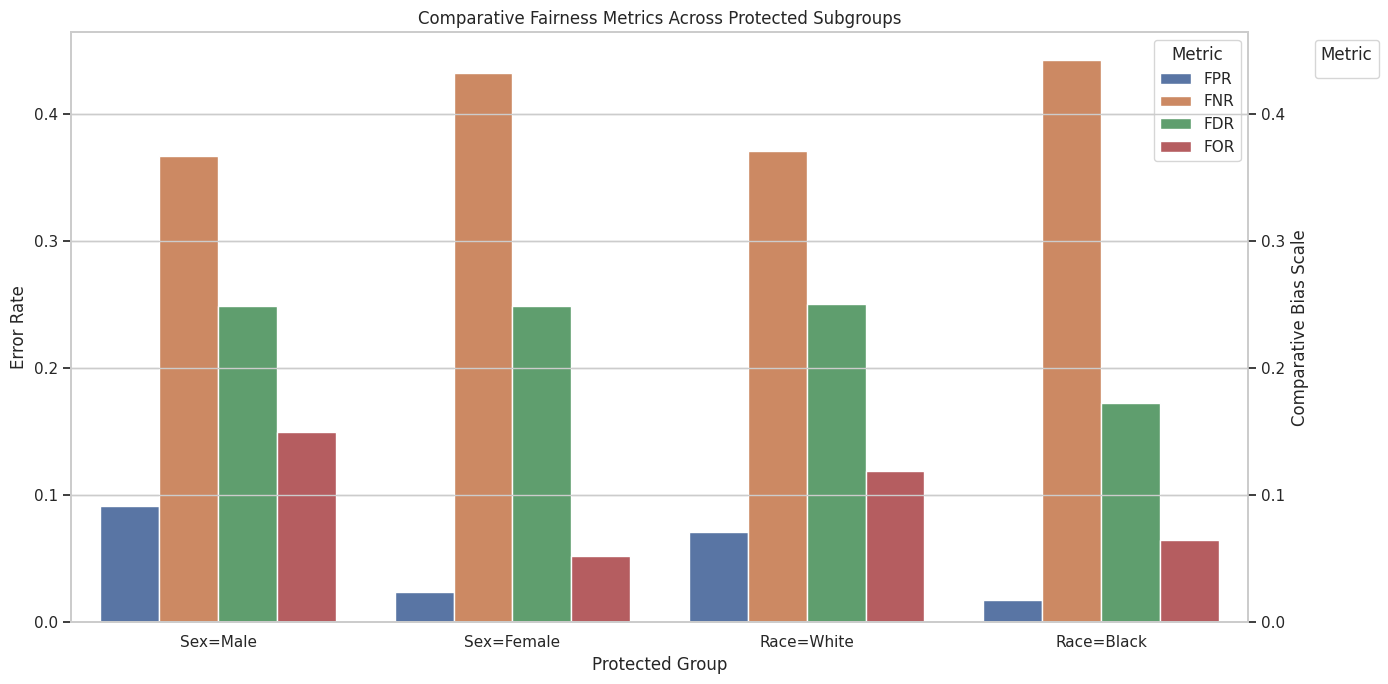

In [16]:

plot_df = fairness_df.melt(id_vars='Group',
                           value_vars=['FPR', 'FNR', 'FDR', 'FOR'],
                           var_name='Metric',
                           value_name='Rate')

fig, ax1 = plt.subplots(figsize=(14,7))

sns.barplot(
    data=plot_df,
    x='Group',
    y='Rate',
    hue='Metric',
    ax=ax1
)

ax1.set_title("Comparative Fairness Metrics Across Protected Subgroups")
ax1.set_ylabel("Error Rate")
ax1.set_xlabel("Protected Group")

# Secondary axis
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())
ax2.set_ylabel("Comparative Bias Scale")

plt.xticks(rotation=45)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



## Step 6 — Structured Bias Analysis

### Observed Systemic Bias Mechanisms

Differences in FPR, FNR, FDR, and FOR across sex and race groups may arise from:

### 1. Historical Dataset Imbalance
The Adult dataset reflects historical socioeconomic disparities, where income opportunities were unevenly distributed.

### 2. Proxy Variable Leakage
Features such as occupation, education, and marital status may indirectly encode demographic inequalities.

### 3. Error Distribution Inequality
- Higher **FNR** for a subgroup suggests qualified individuals are disproportionately denied positive predictions.
- Higher **FPR** may wrongly inflate predicted economic status.
- Higher **FDR/FOR** indicate unequal trustworthiness of predictions.

### 4. Institutional Reproduction
Baseline classifiers may replicate pre-existing structural inequalities unless fairness interventions are introduced.

---

## Conclusion

This baseline Random Forest model demonstrates how predictive systems can generate measurable disparities even before explicit discrimination controls are considered.  
The findings emphasize the necessity of fairness auditing before deployment in socially sensitive domains such as hiring, lending, or public policy.
